# Successive Halving on LCBench — Runtime

In [1]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Data

Loads the two SH-on-LCBench tables and their `brackets` logtable, which logs three runtime metrics per experiment: `virtual_runtime_used` (LCBench's own virtual runtime, taken from YAHPO's `time` output), `gp_fit_runtime_used` (wall-clock time spent fitting the learning-curve GP surrogate), and `overall_runtime_used` (their sum). Since successive halving only ever produces a single bracket per experiment, each `brackets` row corresponds 1:1 to an experiment via `experiment_id`.

In [2]:
TABLE_NAMES = [
    "new_stopping_successive_halving_no_es_vrt",
    "new_stopping_successive_halving_es_vrt",
]
update_data = True

def get_data(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/table.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path=f"priorbai/experiments/successive_halving/{'no_early_stopping' if table_name.endswith('no_es_vrt') else 'with_early_stopping'}/config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            df = experimenter.get_table()
            brackets = experimenter.get_logtable("brackets")
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_csv(cache_path, index=False)
            brackets.to_csv(f"plain_data/{table_name}/brackets.csv", index=False)
            return df, brackets
        except Exception as e:
            print(f"Could not load '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached data for '{table_name}'.")
                brackets_path = f"plain_data/{table_name}/brackets.csv"
                brackets = pd.read_csv(brackets_path) if os.path.exists(brackets_path) else pd.DataFrame()
                return pd.read_csv(cache_path), brackets
            return None, None
    else:
        if not os.path.exists(cache_path):
            print(f"No cache found for '{table_name}', skipping.")
            return None, None
        brackets_path = f"plain_data/{table_name}/brackets.csv"
        brackets = pd.read_csv(brackets_path) if os.path.exists(brackets_path) else pd.DataFrame()
        return pd.read_csv(cache_path), brackets

RUNTIME_COLUMNS = {
    "virtual_runtime": "virtual_runtime_used",
    "gp_fit_runtime": "gp_fit_runtime_used",
    "overall_runtime": "overall_runtime_used",
}

dfs = []
for table_name in TABLE_NAMES:
    df, brackets = get_data(table_name, update_data)
    if df is None or df.empty:
        continue
    df = df[df["status"] == "done"].copy()
    if not brackets.empty:
        # SH has exactly one bracket (bracket 0) per experiment -> 1:1 join on experiment_id
        brackets_0 = brackets[brackets["bracket"] == 0].set_index("experiment_id")
        for col, source_col in RUNTIME_COLUMNS.items():
            df[col] = df["ID"].map(brackets_0[source_col])
    else:
        for col in RUNTIME_COLUMNS:
            df[col] = np.nan
    dfs.append(df)

df_lcbench = pd.concat(dfs, ignore_index=True)
df_lcbench = df_lcbench[df_lcbench["benchmark"] == "lcbench"]

# With use_early_stopping=0 the GP fit still runs every round (it feeds the
# unconditionally-computed stopping-criterion bookkeeping), but its result is
# never acted on -- the run never actually terminates early or changes course
# because of it. That GP-fit cost is therefore not a genuine part of the
# baseline's runtime, so we zero it out and recompute overall_runtime to match.
df_lcbench.loc[df_lcbench["use_early_stopping"] == 0, "gp_fit_runtime"] = 0.0
df_lcbench["overall_runtime"] = df_lcbench["virtual_runtime"] + df_lcbench["gp_fit_runtime"]

n_missing = df_lcbench["overall_runtime"].isna().sum()
print(f"{len(df_lcbench)} completed SH lcbench experiments ({n_missing} missing runtime info)")
df_lcbench.head()

2026-07-27 15:51:00,771  | py-experimenter - INFO     | Found 14 keyfields


2026-07-27 15:51:00,772  | py-experimenter - INFO     | Found 6 resultfields


2026-07-27 15:51:00,772  | py-experimenter - INFO     | Found 2 logtables


2026-07-27 15:51:00,773  | py-experimenter - INFO     | Found logtable new_stopping_successive_halving_no_es_vrt__sh_iterations


2026-07-27 15:51:00,773  | py-experimenter - INFO     | Found logtable new_stopping_successive_halving_no_es_vrt__brackets


...

2026-07-27 15:51:00,939  | py-experimenter - WARNING  | No custom section defined in config


2026-07-27 15:51:00,939  | py-experimenter - WARNING  | No codecarbon section defined in config


2026-07-27 15:51:00,945  | py-experimenter - INFO     | Initialized and connected to database


54400 completed SH lcbench experiments (0 missing runtime info)


,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error,virtual_runtime,gp_fit_runtime,overall_runtime
0,1,__AUTO__,successive_halving,256,lcbench,linear,0,0,0,0,...,1152.0,1,16,0.000752,1,2026-07-27 14:49:01,None,91791.806325,0.0,91791.806325
1,2,__AUTO__,successive_halving,256,lcbench,rbf,0,0,0,0,...,1152.0,1,16,0.000752,1,2026-07-27 14:57:22,None,91791.806325,0.0,91791.806325
2,3,__AUTO__,successive_halving,256,lcbench,matern32,0,0,0,0,...,1152.0,1,16,0.000752,1,2026-07-27 14:54:18,None,91791.806325,0.0,91791.806325
3,4,__AUTO__,successive_halving,256,lcbench,matern52,0,0,0,0,...,1152.0,1,16,0.000752,1,2026-07-27 14:58:07,None,91791.806325,0.0,91791.806325
4,5,__AUTO__,successive_halving,256,lcbench,satexp_rbf,0,0,0,0,...,1152.0,1,16,0.000752,1,2026-07-27 14:50:16,None,91791.806325,0.0,91791.806325


## Prepare Data

In [3]:
PRIOR_RENAME = {
    "uniform": "Uniform",
    "performance": "Performance",
    "rank": "Rank",
    "inverse_rank": "Inverse Rank",
    "indicator": "Indicator",
}

BASELINE_LABEL = "Baseline"

_tab10 = sns.color_palette("tab10", n_colors=6)
PRIOR_COLOR_MAP = {
    "Rank": _tab10[0],
    "Performance": _tab10[1],
    "Indicator": _tab10[2],
    "Inverse Rank": _tab10[3],
    "Uniform": _tab10[4],
    BASELINE_LABEL: _tab10[5],
}

PRIOR_MARKER_MAP = {
    "Rank": "o",
    "Performance": "s",
    "Indicator": "D",
    "Inverse Rank": "^",
    "Uniform": "v",
    BASELINE_LABEL: "P",
}

def prepare_data(df: pd.DataFrame, optimizer: str, kernel: str = "linear") -> pd.DataFrame | None:
    """Method variants (use_early_stopping=1) + baseline (uniform, no early stopping)."""
    method = df[
        (df["optimizer"] == optimizer)
        & (df["use_early_stopping"] == 1)
        & (df["kernel"] == kernel)
    ].copy()
    baseline = df[
        (df["optimizer"] == optimizer)
        & (df["prior_kind"] == "uniform")
        & (df["use_early_stopping"] == 0)
        & (df["kernel"] == kernel)
    ].copy()
    if method.empty and baseline.empty:
        print(f"No data for optimizer '{optimizer}' with kernel='{kernel}', skipping.")
        return None
    baseline["prior_kind"] = BASELINE_LABEL
    combined = pd.concat([method, baseline], ignore_index=True)
    combined["prior_kind"] = combined["prior_kind"].map(PRIOR_RENAME).fillna(combined["prior_kind"])
    return combined

## Plot

In [4]:
sns.set_theme(style="whitegrid", context="talk")

LABEL_SIZE = 13
TICK_SIZE = 11

MARKER_SIZE = 9
LEGEND_MARKER_SIZE = 10
MARKER_EDGE_WIDTH = 2
CAP_SIZE = 3
ALPHA_BASELINE = 0.6
ALPHA_NORMAL = 0.9

FIG_SIZE_PARETO = (7, 4)
FIG_SIZE_LEGEND = (10, 0.7)

YLIM_REGRET = (0, 0.1)

RUNTIME_LABELS = {
    "virtual_runtime": "Virtual Runtime",
    "gp_fit_runtime": "GP Fit Time",
    "overall_runtime": "Overall Runtime",
}

In [5]:
def _ranked_priors(data: pd.DataFrame, runtime_col: str) -> list[str]:
    ranked_priors = (
        data.groupby("prior_kind")[runtime_col]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]
    return ranked_priors


def pareto_plot_by_runtime(data: pd.DataFrame, runtime_col: str, xlim=None, ylim=None) -> plt.Figure:
    ranked_priors = _ranked_priors(data, runtime_col)

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_reg = subset["regret"].mean()
        s_reg = subset["regret"].sem()
        m_rt = subset[runtime_col].mean()
        s_rt = subset[runtime_col].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_rt, m_reg,
            xerr=s_rt, yerr=s_reg,
            fmt=PRIOR_MARKER_MAP.get(prior, "o"),
            label=prior,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            markersize=MARKER_SIZE,
            capsize=CAP_SIZE,
            markeredgewidth=MARKER_EDGE_WIDTH,
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel(RUNTIME_LABELS.get(runtime_col, runtime_col))
    ax.set_ylabel("Regret")
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig


def epsilon_optimal_vs_runtime_plot(data: pd.DataFrame, runtime_col: str, xlim=None, ylim=None) -> plt.Figure:
    ranked_priors = _ranked_priors(data, runtime_col)

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_rt = subset[runtime_col].mean()
        s_rt = subset[runtime_col].sem()
        m_eps = subset["epsilon_optimal"].mean()
        s_eps = subset["epsilon_optimal"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_rt, m_eps,
            xerr=s_rt, yerr=s_eps,
            fmt=PRIOR_MARKER_MAP.get(prior, "o"),
            label=prior,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            markersize=MARKER_SIZE,
            capsize=CAP_SIZE,
            markeredgewidth=MARKER_EDGE_WIDTH,
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel(RUNTIME_LABELS.get(runtime_col, runtime_col))
    ax.set_ylabel("P(epsilon-optimal)")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig


def summary_table_markdown(data: pd.DataFrame) -> str:
    """Rebuttal table: one row per approach, regret and all three runtime metrics as mean +- SEM."""
    ranked_priors = _ranked_priors(data, "overall_runtime")

    lines = [
        "| Approach | Regret | Virtual Runtime | GP Fit Time | Overall Runtime |",
        "|---|---|---|---|---|",
    ]
    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_reg, s_reg = subset["regret"].mean(), subset["regret"].sem()
        m_vrt, s_vrt = subset["virtual_runtime"].mean(), subset["virtual_runtime"].sem()
        m_gp, s_gp = subset["gp_fit_runtime"].mean(), subset["gp_fit_runtime"].sem()
        m_ovr, s_ovr = subset["overall_runtime"].mean(), subset["overall_runtime"].sem()
        lines.append(
            f"| {prior} | {m_reg:.4f} \u00b1 {s_reg:.4f} "
            f"| {m_vrt:.1f} \u00b1 {s_vrt:.1f} "
            f"| {m_gp:.1f} \u00b1 {s_gp:.1f} "
            f"| {m_ovr:.1f} \u00b1 {s_ovr:.1f} |"
        )
    return "\n".join(lines)

## Successive Halving

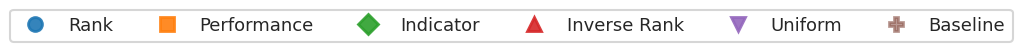

In [6]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/successive_halving_virtual_runtime", exist_ok=True)
_fig_lp.savefig("plots/successive_halving_virtual_runtime/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/successive_halving_virtual_runtime/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

In [7]:
sh_lcbench = prepare_data(df_lcbench, "successive_halving")
if sh_lcbench is not None:
    sh_lcbench = sh_lcbench[(sh_lcbench["sigma0"] == 0.0001) | (sh_lcbench["prior_kind"] == BASELINE_LABEL)]

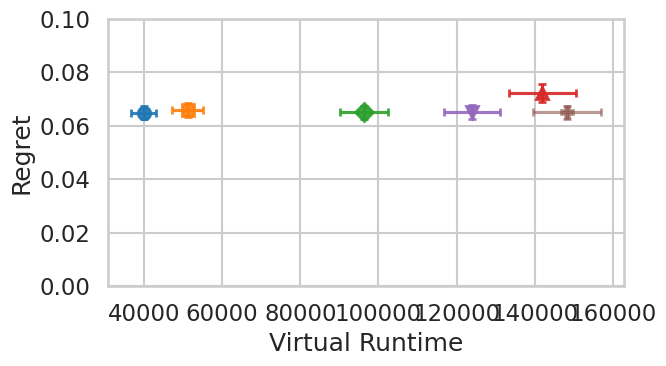

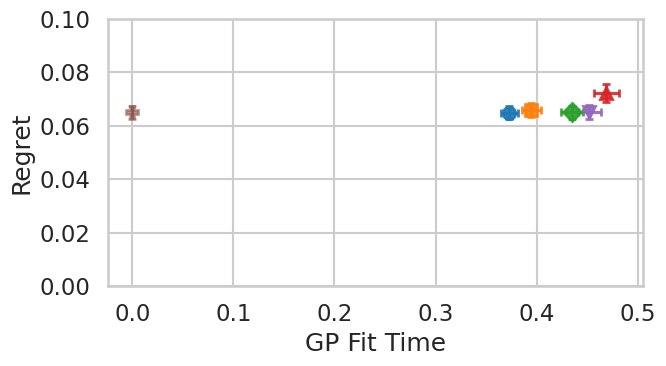

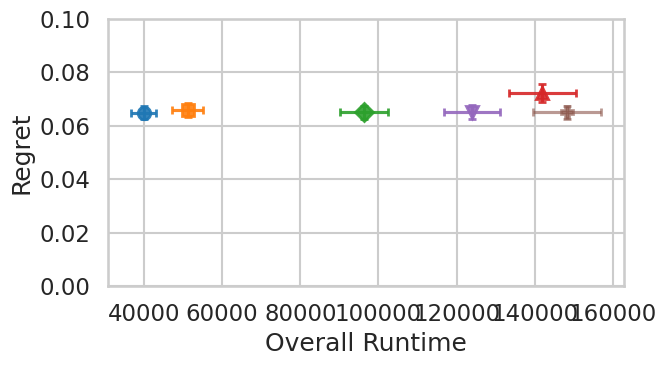

In [8]:
if sh_lcbench is not None:
    for runtime_col in RUNTIME_LABELS:
        fig = pareto_plot_by_runtime(sh_lcbench, runtime_col, ylim=YLIM_REGRET)
        os.makedirs("plots/successive_halving_virtual_runtime", exist_ok=True)
        fig.savefig(f"plots/successive_halving_virtual_runtime/pareto_{runtime_col}.pdf", bbox_inches="tight")
        fig.savefig(f"plots/successive_halving_virtual_runtime/pareto_{runtime_col}.png", bbox_inches="tight", dpi=300)
        plt.show()

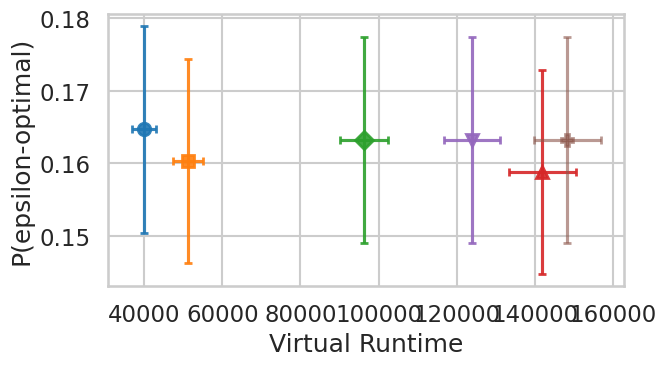

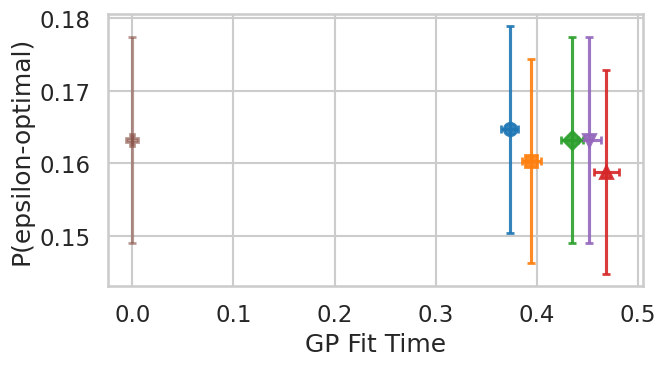

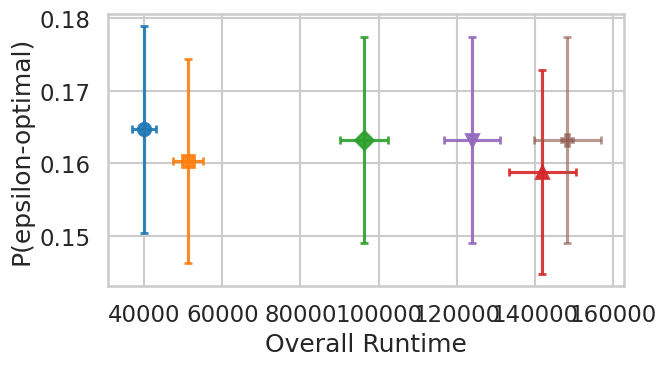

In [9]:
if sh_lcbench is not None:
    for runtime_col in RUNTIME_LABELS:
        fig = epsilon_optimal_vs_runtime_plot(sh_lcbench, runtime_col)
        os.makedirs("plots/successive_halving_virtual_runtime", exist_ok=True)
        fig.savefig(f"plots/successive_halving_virtual_runtime/{runtime_col}_vs_epsilon_optimal.pdf", bbox_inches="tight")
        fig.savefig(f"plots/successive_halving_virtual_runtime/{runtime_col}_vs_epsilon_optimal.png", bbox_inches="tight", dpi=300)
        plt.show()

### Rebuttal Table

In [10]:
from IPython.display import Markdown, display

if sh_lcbench is not None:
    table_md = summary_table_markdown(sh_lcbench)
    os.makedirs("plots/successive_halving_virtual_runtime", exist_ok=True)
    with open("plots/successive_halving_virtual_runtime/rebuttal_table.md", "w") as f:
        f.write(table_md + "\n")
    display(Markdown(table_md))

| Approach | Regret | Virtual Runtime | GP Fit Time | Overall Runtime |
|---|---|---|---|---|
| Rank | 0.0649 ± 0.0025 | 39940.9 ± 3169.8 | 0.4 ± 0.0 | 39941.3 ± 3169.8 |
| Performance | 0.0660 ± 0.0025 | 51236.9 ± 3959.8 | 0.4 ± 0.0 | 51237.3 ± 3959.8 |
| Indicator | 0.0650 ± 0.0025 | 96270.6 ± 6111.5 | 0.4 ± 0.0 | 96271.0 ± 6111.5 |
| Uniform | 0.0651 ± 0.0025 | 123904.5 ± 7170.0 | 0.5 ± 0.0 | 123904.9 ± 7170.0 |
| Inverse Rank | 0.0722 ± 0.0033 | 141965.5 ± 8495.7 | 0.5 ± 0.0 | 141966.0 ± 8495.7 |
| Baseline | 0.0651 ± 0.0025 | 148274.1 ± 8607.6 | 0.0 ± 0.0 | 148274.1 ± 8607.6 |